In [ ]:
# input
pred_file = "../data/pred_info.tsv"
# output
fig_file = "./fig/species_pred_percent.pdf"

In [2]:
import pandas as pd

df = pd.read_table(pred_file)
total = {
    "hs": 3946,
    "sc": 1196,
    "ec": 2181,
    "pf": 872
}

pred = dict()
no_anno = dict()
for k in total.keys():
    df_k = df[df['org'] == k]
    pred[k] = len(df_k)
    no_anno[k] = len(df_k[df_k['anno_level'].map(lambda x: pd.isna(x) or x == "4")])

In [3]:
mapper = {
    "hs": "H. sapiens",
    "sc": "S. cerevisiae",
    "ec": "E. coli",
    "pf": "P. furiosus"
}

x = [mapper[i] for i in pred.keys()]
y = list(pred.values())
ratio = [round(pred[i] / total[i] * 100, 1) for i in pred.keys()]
potential = no_anno.values()

x
y
ratio
potential

['H. sapiens', 'S. cerevisiae', 'E. coli', 'P. furiosus']

[213, 38, 95, 40]

[5.4, 3.2, 4.4, 4.6]

dict_values([40, 3, 13, 10])

<Figure size 240x240 with 0 Axes>

<BarContainer object of 4 artists>

Text(0, 217, '213\n(5.4%)')

Text(1, 42, '38\n(3.2%)')

Text(2, 99, '95\n(4.4%)')

Text(3, 44, '40\n(4.6%)')

Text(0, 0.5, 'Predicted homomer number')

Text(0.5, 0, 'Species')

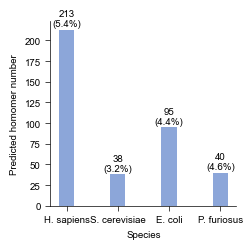

In [5]:
import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

plt.figure(figsize=(2.4, 2.4))

width = 0.3
plt.bar(x, y, width=width)
# plt.bar(x, list(potential), width=width, alpha=1, hatch='//', edgecolor="white", color="#8CA6D9")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


for i, v in enumerate(y):
    plt.text(i, v + 4, f"{y[i]}\n({ratio[i]}%)", ha='center') 

plt.ylabel("Predicted homomer number")
plt.xlabel("Species")
plt.savefig(fig_file, bbox_inches="tight", transparent=True)